In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.5 MB/s eta 0:00:00


#Download Dataset

In [2]:
from google.colab import files
files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


{'online_shoppers_intention.csv': b'Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue\r\n0,0,0,0,1,0,0.2,0.2,0,0,Feb,1,1,1,1,Returning_Visitor,FALSE,FALSE\r\n0,0,0,0,2,64,0,0.1,0,0,Feb,2,2,1,2,Returning_Visitor,FALSE,FALSE\r\n0,0,0,0,1,0,0.2,0.2,0,0,Feb,4,1,9,3,Returning_Visitor,FALSE,FALSE\r\n0,0,0,0,2,2.666666667,0.05,0.14,0,0,Feb,3,2,2,4,Returning_Visitor,FALSE,FALSE\r\n0,0,0,0,10,627.5,0.02,0.05,0,0,Feb,3,3,1,4,Returning_Visitor,TRUE,FALSE\r\n0,0,0,0,19,154.2166667,0.015789474,0.024561404,0,0,Feb,2,2,1,3,Returning_Visitor,FALSE,FALSE\r\n0,0,0,0,1,0,0.2,0.2,0,0.4,Feb,2,4,3,3,Returning_Visitor,FALSE,FALSE\r\n1,0,0,0,0,0,0.2,0.2,0,0,Feb,1,2,1,5,Returning_Visitor,TRUE,FALSE\r\n0,0,0,0,2,37,0,0.1,0,0.8,Feb,2,2,2,3,Returning_Visitor,FALSE,FALSE\r\n0,0,0,0,3,738,0,0.022222222,0,0.4,Feb,2,4,1,2,Returning_V

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!unzip unsw-nb15.zip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:01<00:00, 120MB/s]

Archive:  unsw-nb15.zip
  inflating: NUSW-NB15_features.csv  
  inflating: UNSW-NB15_1.csv         
  inflating: UNSW-NB15_2.csv         
  inflating: UNSW-NB15_3.csv         
  inflating: UNSW-NB15_4.csv         
  inflating: UNSW-NB15_LIST_EVENTS.csv  
  inflating: UNSW_NB15_testing-set.csv  
  inflating: UNSW_NB15_training-set.csv  


#Load Dataset

In [5]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

df = pd.concat([train_df, test_df], axis=0)

print(df.shape)
df.head()

(257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


#Understand Dataset

In [6]:
print(df.info())
print(df.isnull().sum())
print(df['label'].value_counts())
print(df['attack_cat'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 257673 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  sinpkt 

In [9]:
df = df.drop_duplicates()

df = df.drop(columns=['id'], errors='ignore')

df = df.fillna(0)

print(df.shape)

(257673, 44)


#Visualize Attack Distribution

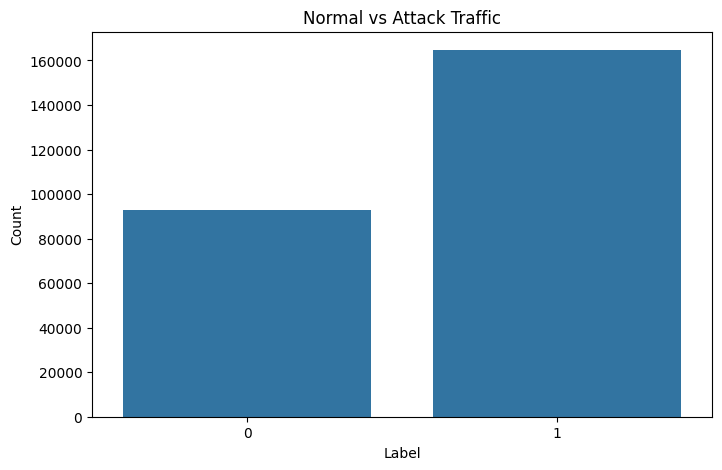

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=df['label'])
plt.title("Normal vs Attack Traffic")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

#Prepare Features and Target

In [11]:
X = df.drop(columns=['label', 'attack_cat'], errors='ignore')
y = df['label']

#Convert Text Columns into Numbers

In [12]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=['object']).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

print("Categorical columns encoded:", list(categorical_cols))

Categorical columns encoded: ['proto', 'service', 'state']


#Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(206138, 42)
(51535, 42)


#Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train Multiple Models

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.899175,0.885918,0.966722,0.924558
1,Decision Tree,0.937208,0.951558,0.950114,0.950836
2,Random Forest,0.952498,0.964330,0.961227,0.962776


#Select Best Model

In [16]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


#Cross Validation

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')

print("Cross Validation F1 Scores:", cv_scores)
print("Average CV F1 Score:", cv_scores.mean())

Cross Validation F1 Scores: [0.95861925 0.96125595 0.96063082 0.96039887 0.96030282]
Average CV F1 Score: 0.9602415392310115


#Final Evaluation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     18600
           1       0.96      0.96      0.96     32935

    accuracy                           0.95     51535
   macro avg       0.95      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535



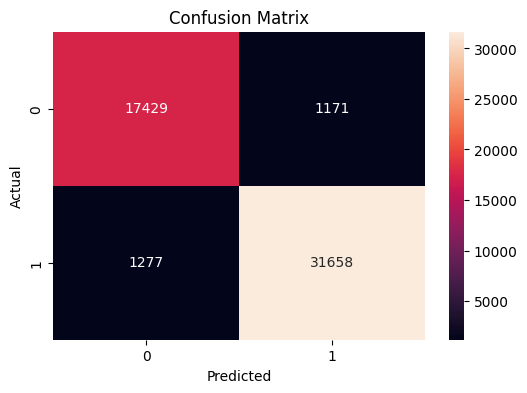

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Feature Importance

In [20]:
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
31,ct_state_ttl,0.103623
9,sttl,0.089868
8,rate,0.067039
11,sload,0.063070
12,dload,0.053269
40,ct_srv_dst,0.045731
6,sbytes,0.041575
26,smean,0.039332
25,ackdat,0.034689
7,dbytes,0.034214


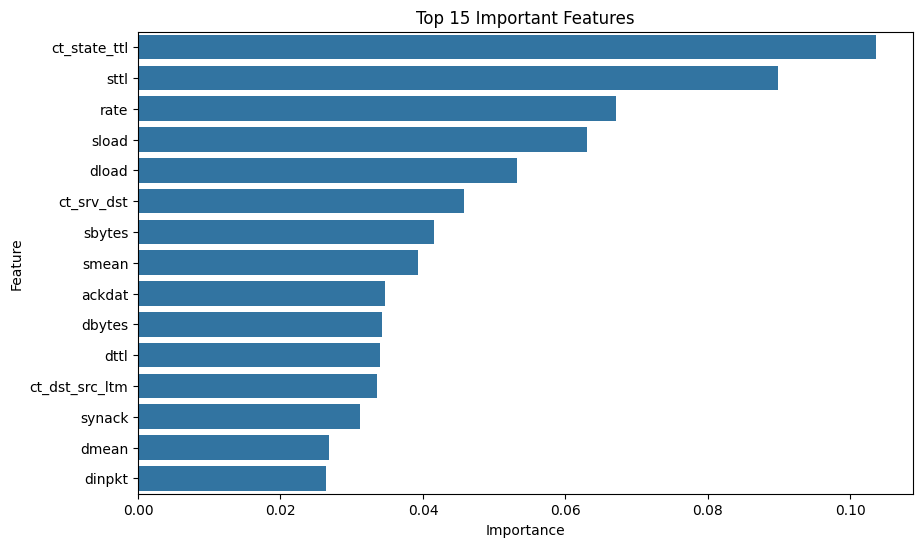

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features")
plt.show()

#Save Model Files

In [22]:
import joblib

joblib.dump(best_model, "cybershield_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Model files saved successfully.")

Model files saved successfully.


In [23]:
from google.colab import files

files.download("cybershield_model.pkl")
files.download("scaler.pkl")
files.download("encoders.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>